In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (7043, 21)

Column types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract        

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("TotalCharges missing after coercion:", df['TotalCharges'].isnull().sum())
print("Rows with missing TotalCharges:\n", df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

TotalCharges missing after coercion: 11
Rows with missing TotalCharges:
       customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [5]:
print(df['Churn'].value_counts())
print("\nChurn rate:", df['Churn'].value_counts(normalize=True)['Yes'])

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 0.2653698707936959


In [6]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f"\n{col}:\n", df[col].value_counts().head())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3794.737500
max      72.000000      118.750000   8684.800000

Contract:
 Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService:
 InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod:
 PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


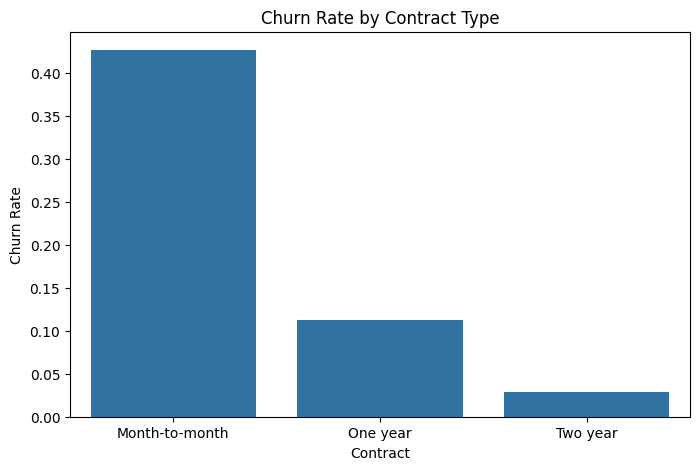

In [7]:
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)

sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.show()

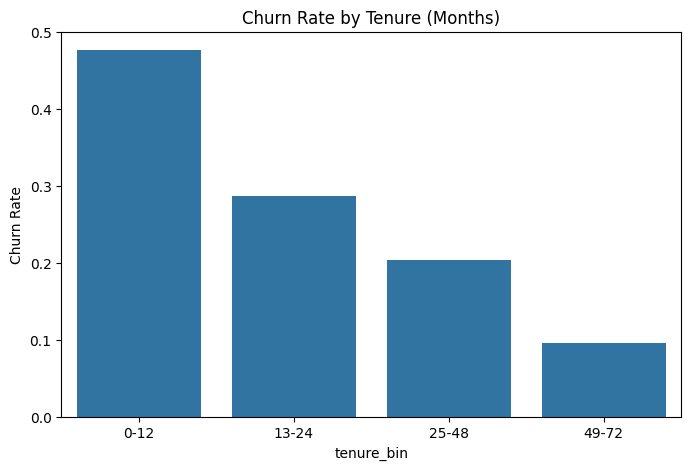

In [8]:
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12', '13-24', '25-48', '49-72'])

plt.figure(figsize=(8, 5))
tenure_churn = df.groupby('tenure_bin')['Churn'].apply(lambda x: (x == 'Yes').mean())

sns.barplot(x=tenure_churn.index, y=tenure_churn.values)
plt.title('Churn Rate by Tenure (Months)')
plt.ylabel('Churn Rate')
plt.show()

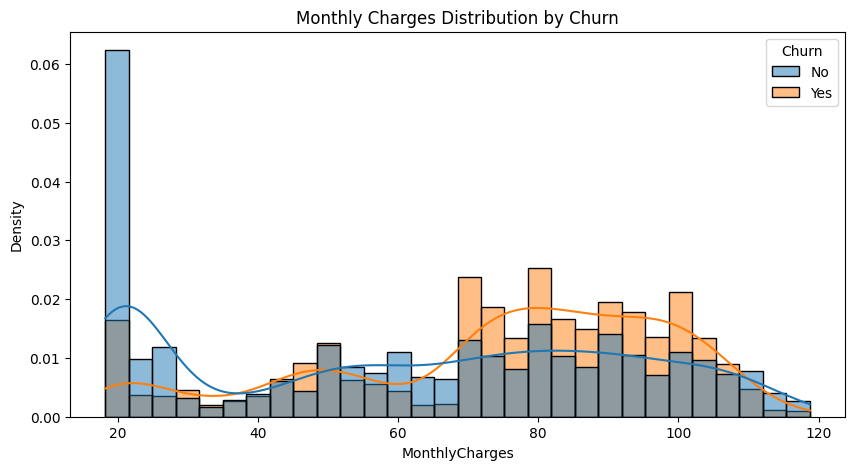

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, stat='density', common_norm=False)
plt.title('Monthly Charges Distribution by Churn')
plt.show()